# FlatFieldVAE demo

This notebook fits `comicsnet.FlatFieldVAE` to the synthetic data cube in
`../data/tutorial_demo.fits`, generated by `generate_demo_data.ipynb`.
The data contain a fixed additive background, a fixed sensitivity pattern,
a varying uniform background level, a moving source, and counting noise.

The model reconstructs each frame as `bias + flux * flat`. Bias and flat
are shared across frames; a small MLP estimates a Gaussian posterior for
one flux value per frame. The source mask stays fixed during fitting.
The known `FLAT` extension is used only to evaluate the recovered relative
sensitivity, not to train or initialize the model.

Results are saved to `../data/tutorial_FlatFieldVAE.fits`: the primary HDU
contains the residual cube; `MODEL`, `MASK`, and `ERROR` contain the
background, source mask, and predicted residual standard deviation.
`FLAT` stores the learned mean-one 2D relative sensitivity.


In [1]:
import matplotlib.pyplot as plt
from matplotlib import rcParams
import jax
import numpy as np
import astropy.io.fits as fits

from comicsnet import Config, FlatFieldVAE, fit

jax.config.update('jax_enable_x64', True)

rcParams['image.origin'] = 'lower'
rcParams['legend.frameon'] = False

## Demo data

Load the data cube from the primary HDU and the source mask from `MASK`.
Both have shape `(time, y, x)`; mask values of 1 exclude source pixels,
while 0 marks observed pixels. Normalize the known 2D `FLAT` image to
mean one for comparison with the learned flat. The first plot displays
the first six frames after subtracting the temporal mean image.
The original cube is passed to `fit`.


In [2]:
with fits.open('../data/tutorial_demo.fits') as hdul:
  cube = hdul[0].data.copy()
  mask = hdul['MASK'].data.copy()
  true_flat = hdul['FLAT'].data.copy()
nz, ny, nx = cube.shape
true_flat = true_flat / np.mean(true_flat)

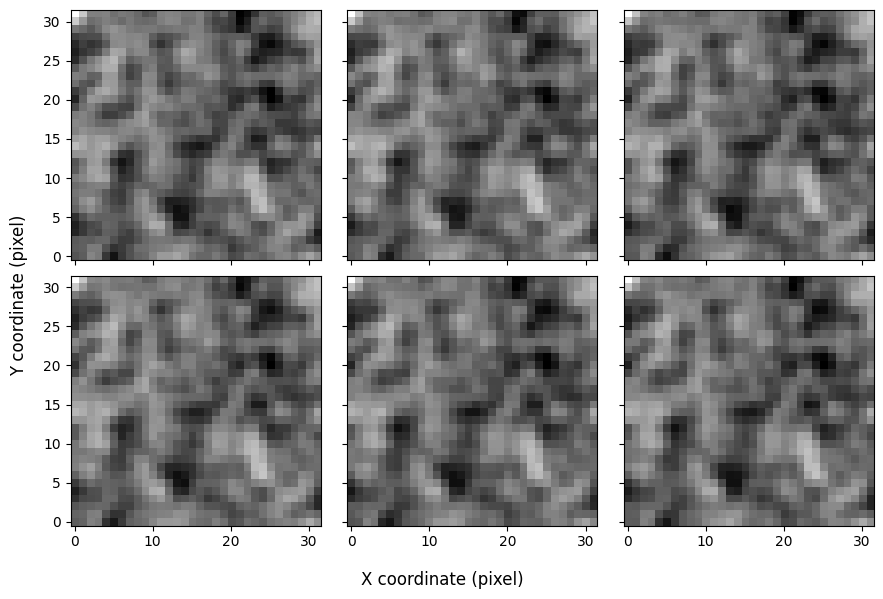

In [3]:
fig, axes = plt.subplots(2, 3, figsize=(9, 6), sharex=True, sharey=True)

for n, ax in enumerate(axes.flatten()):
  ax.imshow(cube[n] - cube.mean(axis=0), cmap='gray')

fig.supxlabel('X coordinate (pixel)', fontsize=12)
fig.supylabel('Y coordinate (pixel)', fontsize=12)

fig.tight_layout()
plt.show()

## Fit FlatFieldVAE with a fixed mask

Pass the source mask to `fit` with `update_mask=False`. Each optimizer
update uses one randomly selected full detector frame. The mask is also
used in final prediction.

The encoder concatenates the weighted image, observation weights
(`1 - mask`), learned bias image, and learned mean-one flat image,
then flattens the four channels. Bias and flat are supplied at all pixels,
including masked locations, and gradients pass through both channels.
An MLP with `depth=2` hidden layers of width `hidden_dim=4` estimates the
mean and log variance of a scalar Gaussian flux posterior. Hidden layers
use GELU; the final layer is linear. `depth=0` selects a single linear
transformation with two outputs.

Training samples flux using
`flux = flux_mean + exp(0.5 * flux_logvar) * epsilon`, where `epsilon`
is standard normal. The loss adds a KL divergence to a standard normal
prior, weighted by `Config.beta` (the default is `1e-4`).
Bias and flat remain deterministic learned arrays, not sampled variables.

Bias and the raw flat perturbation `dflat` start at zero. The flat is
`1 + flat_variation_scale * (tanh(dflat) - mean(tanh(dflat)))`.
It starts at one and retains mean one. With `flat_variation_scale=0.05`,
deviations are bounded by 0.10, not 0.05, because mean subtraction can
double the perturbation range. The scale must be in `[0, 0.5)` to
guarantee positive sensitivity.

The decoder is `bias + flux * flat`, so its derivative with respect to
flux is exactly the learned flat. Output log variance is learned per
pixel and shared across frames, separately from the flux posterior.

The settings follow the FlatFieldAE tutorial: one outer step, 500,000
inner steps, and an initial learning rate of `1e-3`, halved every 50,000
updates. By default, `fit` standardizes the cube before training.
The model bias and flux remain in standardized units, and flux may be
negative. The prior regularizes flux, but does not make bias a calibrated
dark image. The flat is dimensionless and can be compared directly with
the normalized simulated sensitivity.


In [4]:
config = Config(
  outer_steps=1,
  inner_steps=2000000,
  learning_rate=lambda n: 1e-4 * 0.5 ** (n / 1e5),
  adam_epsilon=1e-6,
  update_mask=False,
  seed=1,
)

model_key = jax.random.PRNGKey(2)
model = FlatFieldVAE(
  frame_shape=(ny, nx),
  hidden_dim=4,
  depth=2,
  flat_variation_scale=0.05,
  key=model_key,
)

result = fit(model, cube, mask=mask, config=config)

The plot shows the last 20,000 optimization steps. Each loss value is the
Gaussian negative log likelihood averaged over unmasked pixels in one
randomly selected frame, plus `beta` times the flux posterior KL
divergence. Training uses standardized data and a sampled flux value.
The fixed mask is used at every step; the loss is not evaluated over the
full data cube.


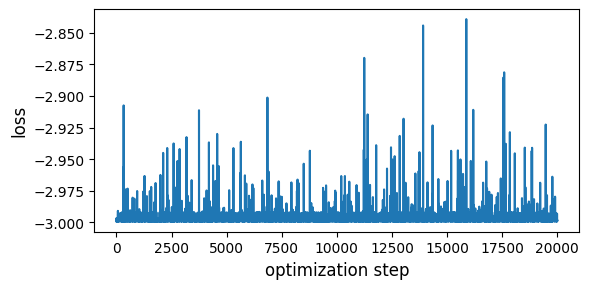

In [9]:
fig, ax = plt.subplots(figsize=(6, 3))

ax.plot(result.losses[-20000:])

ax.set_xlabel('optimization step', fontsize=12)
ax.set_ylabel('loss', fontsize=12)

fig.tight_layout()
plt.show()

## Inspect the reconstructed background

Compare the input, background, residual, fixed mask, masked residual, and
uncertainty in frame 16. Final prediction decodes the flux posterior mean
without sampling. Background, residual, and uncertainty are in input units.
Uncertainty is the modeled residual standard deviation; it includes
neither flux posterior variance nor uncertainty of the estimated flat.
Residuals are not flat-field corrected.


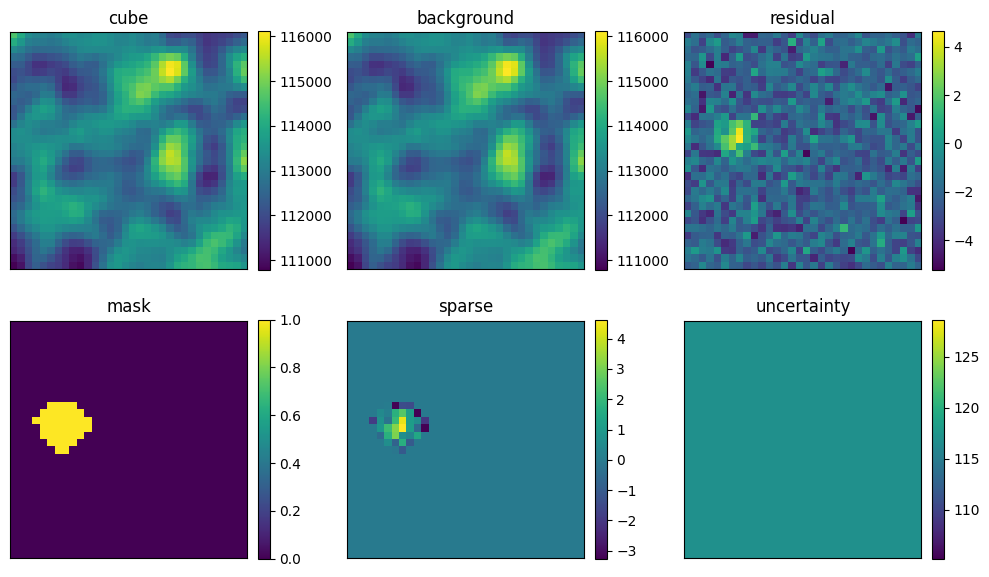

In [6]:
frame_index = 16

fig, axes = plt.subplots(2, 3, figsize=(10, 6))
items = [
  ('cube', cube[frame_index]),
  ('background', result.background[frame_index]),
  ('residual', result.residual[frame_index]),
  ('mask', result.mask[frame_index]),
  ('sparse', result.sparse[frame_index]),
  ('uncertainty', result.uncertainty[frame_index]),
]

for axis, (title, image) in zip(axes.ravel(), items):
  handle = axis.imshow(image, origin='lower', cmap='viridis')
  axis.set_title(title)
  axis.set_xticks([])
  axis.set_yticks([])
  fig.colorbar(handle, ax=axis, fraction=0.046, pad=0.04)

fig.tight_layout()
plt.show()

## Compare the estimated flat with the simulation

Read the fixed relative sensitivity from `result.model.flat`. Compare
it with the normalized input `FLAT` map and report the RMS relative error.
The two flat images share a color scale. The bias panel is in the model's
standardized units and is not compared directly with `CONST`.

This comparison evaluates the sensitivity pattern, independently of the
background reconstruction loss. Reliable estimates require background
variation and observations at multiple flux levels for each pixel.
Pixels always excluded by the mask have no direct data constraint on
their sensitivity; normalization alone does not calibrate them.


Flat relative RMS error: 0.0046%


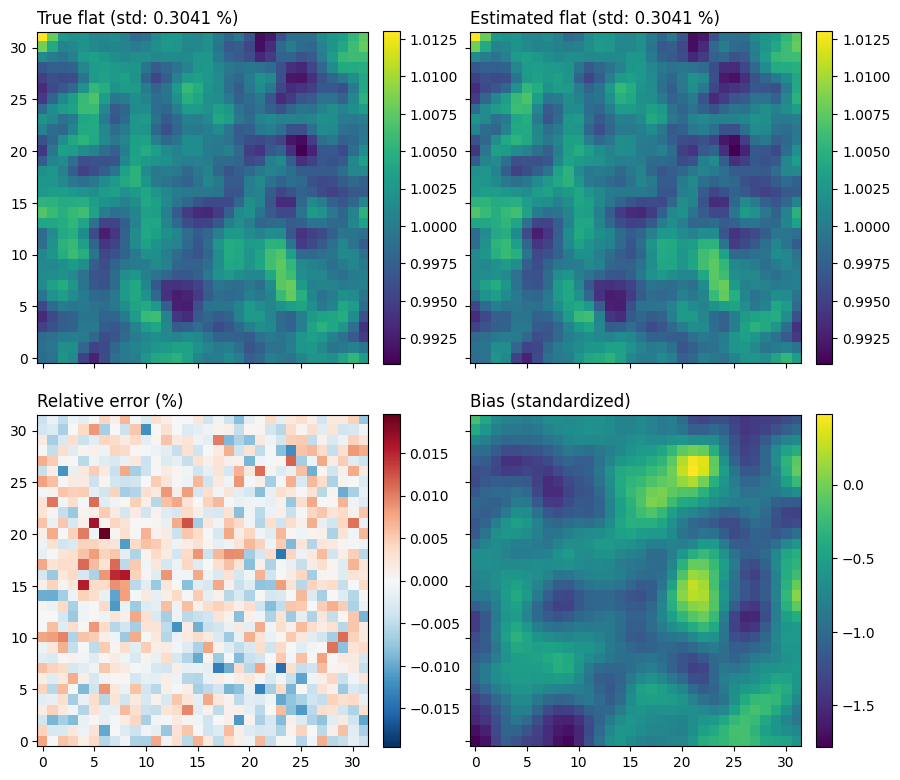

In [7]:
estimated_flat = np.asarray(result.model.flat)
relative_error = estimated_flat / true_flat - 1.0
rms_error = np.sqrt(np.mean(relative_error**2))
std_true = true_flat.std()
std_estimate = estimated_flat.std()
print(f'Flat relative RMS error: {100 * rms_error:.4f}%')

vmin = min(true_flat.min(), estimated_flat.min())
vmax = max(true_flat.max(), estimated_flat.max())
error_limit = max(float(np.max(np.abs(relative_error))), 1.0e-6)
fig, axes = plt.subplots(2, 2, figsize=(9, 8), sharex=True, sharey=True)
items = [
  (f'True flat (std: {100 * std_true:.4f} %)', true_flat, 'viridis', vmin, vmax),
  (
    f'Estimated flat (std: {100 * std_estimate:.4f} %)',
    estimated_flat,
    'viridis',
    vmin,
    vmax,
  ),
  (
    'Relative error (%)',
    100 * relative_error,
    'RdBu_r',
    -100 * error_limit,
    100 * error_limit,
  ),
  ('Bias (standardized)', np.asarray(result.model.bias), 'viridis', None, None),
]

for axis, (title, image, cmap, lower, upper) in zip(axes.ravel(), items):
  handle = axis.imshow(image, cmap=cmap, vmin=lower, vmax=upper)
  axis.set_title(title, loc='left')
  fig.colorbar(handle, ax=axis, fraction=0.046, pad=0.04)

fig.tight_layout()
plt.show()

In [8]:
hdul = fits.HDUList([
  fits.PrimaryHDU(data=result.residual),
  fits.ImageHDU(data=result.background, name='MODEL'),
  fits.ImageHDU(data=result.mask.astype('int16'), name='MASK'),
  fits.ImageHDU(data=result.uncertainty, name='ERROR'),
  fits.ImageHDU(data=estimated_flat, name='FLAT'),
])
hdul.writeto('../data/tutorial_FlatFieldVAE.fits', overwrite=True)